# Analyzation of GraphCast_small on the 18th February 2018

Graph with 3 lines: the observed data, the predicted data (1 step), the predicted data (longrange)

In [1]:
from pkg.data_preparation.download_input import prepare_graphcast_input
from pkg.data_preparation.run_graphcast_forecast import run_forecast
from pkg.gcs_utils.client import download_file

## Curve

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

## All together

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/1953798604.py:18: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/1953798604.py:18: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/1953798604.py:18: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/19537

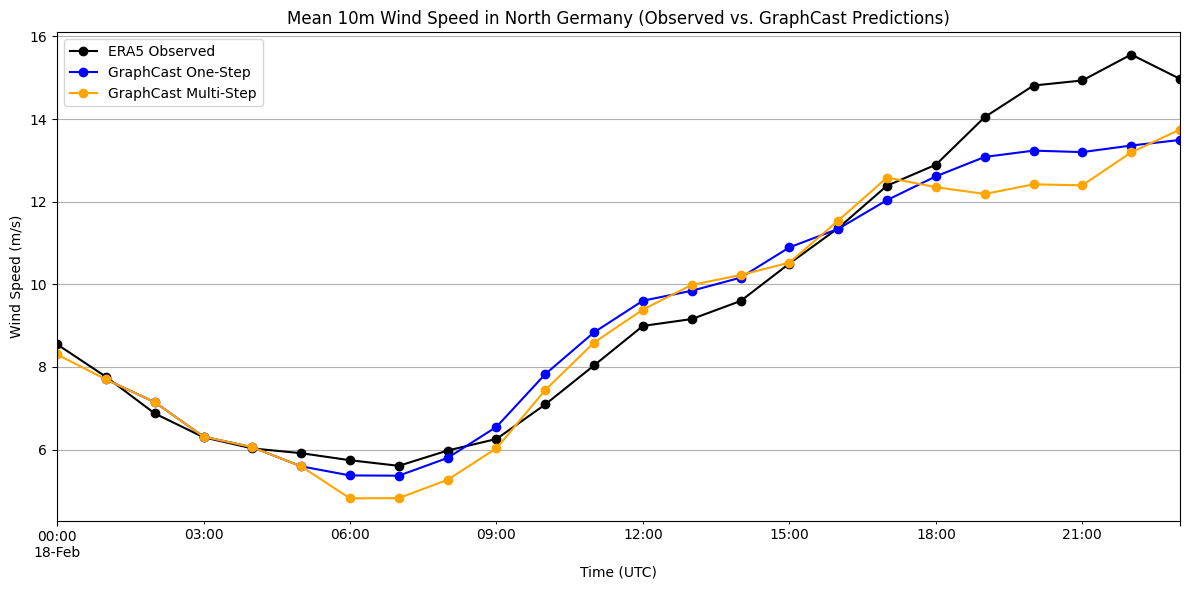

In [16]:
# ---------- 1. Real Data ----------
ds_real = xr.open_dataset("data/north_germany_wind_20220218_1res.nc")
u = ds_real['u10']
v = ds_real['v10']
wind_speed = np.sqrt(u**2 + v**2)
mean_wind_real = wind_speed.mean(dim=["latitude", "longitude"])
real_series = mean_wind_real.to_series()

# ---------- 2. Single-Step Prediction ----------
base_dir_single = "data/predictions_curve_one_step"
time_steps = [f"{h:02d}00" for h in range(1, 24)]
all_data_single = []

for t in time_steps:
    path = os.path.join(base_dir_single, f"curve_prediction_one_step_2022-02-18_{t}.nc")
    if not os.path.exists(path):
        continue
    ds = xr.open_dataset(path)
    forecast_time = np.datetime64(f"2022-02-18T{t[:2]}:00")
    ds = ds.drop_vars("time").assign_coords(time=("time", [forecast_time]))
    sub = ds.sel(lat=slice(55.0, 53.0), lon=slice(7.5, 10.5))
    u10 = sub["10m_u_component_of_wind"]
    v10 = sub["10m_v_component_of_wind"]
    ws = np.sqrt(u10**2 + v10**2)
    spatial_mean = ws.mean(dim=["lat", "lon"]).isel(batch=0, drop=True)
    clean = spatial_mean.drop_vars(["number", "expver"], errors="ignore")
    all_data_single.append(clean)

combined_single = xr.concat(all_data_single, dim="time").sortby("time")
single_series = combined_single.to_series()

# ---------- 3. Multi-Step Prediction ----------
base_dir_multi = "data/predictions_curve_multiple_step"
start_times = ["0000", "0100", "0200", "0300", "0400", "0500"]
all_data_multi = []

for start in start_times:
    path = f"{base_dir_multi}/curve_prediction_multiple_steps_2022-02-18_start_{start}.nc"
    ds = xr.open_dataset(path)
    forecast_times = [
        np.datetime64(f"2022-02-18T{start[:2]}:{start[2:]}") + np.timedelta64(6 * i, "h")
        for i in range(ds.sizes["time"])
    ]
    ds = ds.assign_coords(time=("time", forecast_times))
    sub = ds.sel(lat=slice(55.0, 53.0), lon=slice(7.5, 10.5))
    u10 = sub["10m_u_component_of_wind"]
    v10 = sub["10m_v_component_of_wind"]
    ws = np.sqrt(u10**2 + v10**2)
    spatial_mean = ws.mean(dim=["lat", "lon"]).isel(batch=0, drop=True)
    clean = spatial_mean.drop_vars(["number", "expver"], errors="ignore")
    all_data_multi.append(clean)

combined_multi = xr.concat(all_data_multi, dim="time").sortby("time")
multi_series = combined_multi.to_series()

# ---------- Plot Combined ----------
plt.figure(figsize=(12, 6))
real_series.plot(marker='o', label="ERA5 Observed", color='black')
single_series.plot(marker='o', label="GraphCast One-Step", color='blue')
multi_series.plot(marker='o', label="GraphCast Multi-Step", color='orange')

plt.title("Mean 10m Wind Speed in North Germany (Observed vs. GraphCast Predictions)")
plt.xlabel("Time (UTC)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Real data

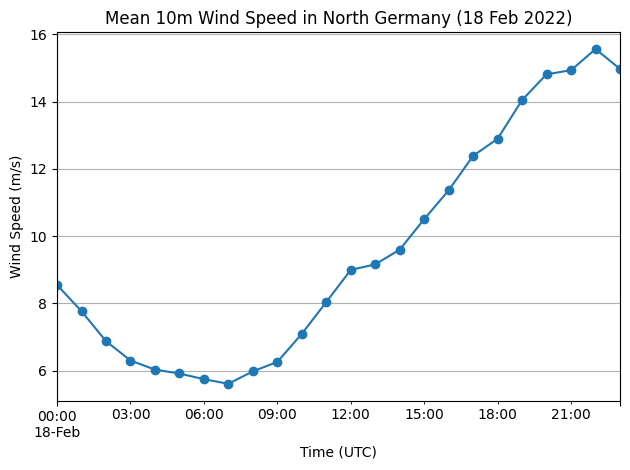

In [15]:
# Load dataset
ds = xr.open_dataset("data/north_germany_wind_20220218_1res.nc")

# Compute wind speed magnitude
u = ds['u10']
v = ds['v10']
wind_speed = np.sqrt(u**2 + v**2)

# Compute spatial mean
mean_wind = wind_speed.mean(dim=["latitude", "longitude"])

# Plot with dots
mean_wind_series = mean_wind.to_series()
mean_wind_series.plot(marker='o')
plt.title("Mean 10m Wind Speed in North Germany (18 Feb 2022)")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time (UTC)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Single steps

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/2366186716.py:12: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/2366186716.py:12: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/2366186716.py:12: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/23661

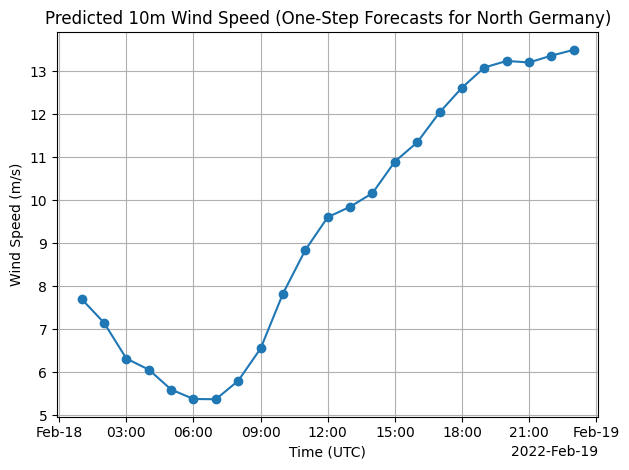

In [3]:
# Define the folder and time range
base_dir = "data/predictions_curve_one_step"
time_steps = [f"{h:02d}00" for h in range(1, 24)]  # 0100 to 2300

all_data = []

for t in time_steps:
    # Load file
    path = os.path.join(base_dir, f"curve_prediction_one_step_2022-02-18_{t}.nc")
    if not os.path.exists(path):
        continue  # skip missing files
    ds = xr.open_dataset(path)

    # Assign proper time based on file name (prediction is for +6h)
    forecast_time = np.datetime64(f"2022-02-18T{t[:2]}:00")

    # Safely assign new time coordinate
    ds = ds.drop_vars("time").assign_coords(time=("time", [forecast_time]))


    # Subset region
    sub = ds.sel(lat=slice(55.0, 53.0), lon=slice(7.5, 10.5))

    # Compute 10 m wind speed
    u10 = sub["10m_u_component_of_wind"]
    v10 = sub["10m_v_component_of_wind"]
    ws = np.sqrt(u10**2 + v10**2)

    # Mean over region and remove singleton batch
    spatial_mean = ws.mean(dim=["lat", "lon"]).isel(batch=0, drop=True)

    # Keep only time + value
    clean = spatial_mean.drop_vars(["number", "expver"], errors="ignore")
    all_data.append(clean)

# Concatenate and sort along time
combined = xr.concat(all_data, dim="time").sortby("time")

# Plot
combined.plot(marker='o')
plt.title("Predicted 10m Wind Speed (One-Step Forecasts for North Germany)")
plt.xlabel("Time (UTC)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Multi-steps

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/3582451075.py:9: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/3582451075.py:9: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/3582451075.py:9: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16333/35824510

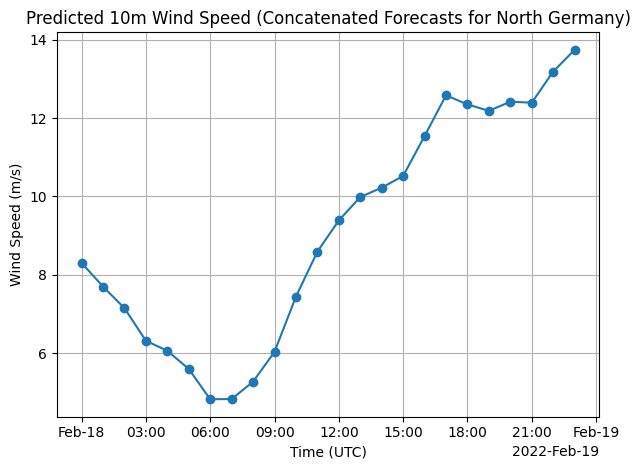

In [12]:
base_dir = "data/predictions_curve_multiple_step"
start_times = ["0000", "0100", "0200", "0300", "0400", "0500"]

all_data = []

for start in start_times:
    # Load file
    path = f"{base_dir}/curve_prediction_multiple_steps_2022-02-18_start_{start}.nc"
    ds = xr.open_dataset(path)

    forecast_times = [
        np.datetime64(f"2022-02-18T{start[:2]}:{start[2:]}") + np.timedelta64(6 * i, "h")
        for i in range(ds.sizes["time"])
    ]
    ds = ds.assign_coords(time=("time", forecast_times))


    # Subset region
    sub = ds.sel(lat=slice(55.0, 53.0), lon=slice(7.5, 10.5))

    # Compute 10 m wind speed
    u10 = sub["10m_u_component_of_wind"]
    v10 = sub["10m_v_component_of_wind"]
    ws = np.sqrt(u10**2 + v10**2)

    # Mean over region and remove singleton batch
    spatial_mean = ws.mean(dim=["lat", "lon"]).isel(batch=0, drop=True)

    # Keep only time + value
    clean = spatial_mean.drop_vars(["number", "expver"], errors="ignore")
    all_data.append(clean)

# Sort by time after concatenation
combined = xr.concat(all_data, dim="time").sortby("time")

# Plot as one continuous curve
combined.plot(marker='o')
plt.title("Predicted 10m Wind Speed (Concatenated Forecasts for North Germany)")
plt.xlabel("Time (UTC)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()



## Download data and make predictions

In [17]:
time="1700"
start_time="17:00"

prepare_graphcast_input(
    date="2022-02-17",
    start_time=start_time,
    n_steps=6,
    step_hours=6,
    levels=13,
    resolution=1.0,
    output_folder="data/input_curve_multiple_steps",
    name=f"zeynep_graphcast_start_20220217_{time}",
    upload_to_gcs=False
)

2025-05-17 12:05:17,526 WARNING [2025-05-15T00:00:00] Scheduled maintenance of the Data Stores Cloud Infrastructure - 19 May 2025. Please follow status [here](https://status.ecmwf.int/) or in our [forum](https://forum.ecmwf.int/t/scheduled-maintenance-of-the-data-stores-cloud-infrastructure-19-may-2025/13056/1)
2025-05-17 12:05:17,527 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:datapi.legacy_api_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-05-17 12:05:17,528 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.


📥 Downloading pressure-level data...


2025-05-17 12:05:17,738 INFO Request ID is 66656715-d2e0-4070-ad1d-98d25f6332f2
INFO:datapi.legacy_api_client:Request ID is 66656715-d2e0-4070-ad1d-98d25f6332f2
2025-05-17 12:05:17,824 INFO status has been updated to accepted
INFO:datapi.legacy_api_client:status has been updated to accepted
2025-05-17 12:05:50,672 INFO status has been updated to running
INFO:datapi.legacy_api_client:status has been updated to running
2025-05-17 12:06:07,852 INFO status has been updated to successful
INFO:datapi.legacy_api_client:status has been updated to successful


effecab51fbdd0dd7ce493d293beb6c6.nc:   0%|          | 0.00/18.9M [00:00<?, ?B/s]

📥 Downloading surface-level data...


...

d7f5f0c6b39b8abf85a6e33a64f38773.zip:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

Extracting surface ZIP...
📥 Downloading land-sea mask...


2025-05-17 12:08:47,309 INFO Request ID is c7680e65-40c4-451f-9933-e3ac2a28319b
INFO:datapi.legacy_api_client:Request ID is c7680e65-40c4-451f-9933-e3ac2a28319b
2025-05-17 12:08:47,379 INFO status has been updated to accepted
INFO:datapi.legacy_api_client:status has been updated to accepted
2025-05-17 12:09:20,310 INFO status has been updated to running
INFO:datapi.legacy_api_client:status has been updated to running
2025-05-17 12:09:37,646 INFO status has been updated to successful
INFO:datapi.legacy_api_client:status has been updated to successful


406c17b11a381052370c4aff37169d45.nc:   0%|          | 0.00/83.8k [00:00<?, ?B/s]

✅ Saved locally: data/input_curve_multiple_steps/zeynep_graphcast_start_20220217_1700/graphcast_ready_input_zeynep_graphcast_start_20220217_1700.nc


In [19]:
from datetime import datetime, timedelta

# Initialize starting times
time_str = "1400"
start_str = "0200"

# Convert to datetime objects
time = datetime.strptime(time_str, "%H%M")
start = datetime.strptime(start_str, "%H%M")

# Loop until time reaches 17:00
while time <= datetime.strptime("1700", "%H%M"):
    # Format current times
    time_fmt = time.strftime("%H%M")
    start_fmt = start.strftime("%H%M")

    # Run forecast
    run_forecast(
        model_name="graphcast_small",
        input_path=(
            f"data/input_curve_multiple_steps/graphcast_ready_input_zeynep_graphcast_start_20220217_{time_fmt}.nc"
        ),
        output_name=f"curve_prediction_multiple_steps_2022-02-18_start_{start_fmt}",
        upload_to_gcs=False,
        predictions_folder="data/predictions_curve_multiple_step",
        forecast_hours=24
    )

    # Increment times by 1 hour
    time += timedelta(hours=1)
    start += timedelta(hours=1)


📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: data/predictions_curve_multiple_step/curve_prediction_multiple_steps_2022-02-18_start_0200.nc
📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: data/predictions_curve_multiple_step/curve_prediction_multiple_steps_2022-02-18_start_0300.nc
📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: data/predictions_curve_multiple_step/curve_prediction_multiple_steps_2022-02-18_start_0400.nc
📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: data/predictions_curve_multiple_step/curve_prediction_multiple_steps_2022-02-18_start_0500.nc


In [ ]:
time="1200"
start="0000"

run_forecast(
    model_name="graphcast_small",
    input_path=(
        f"data/input_curve_multiple_steps/graphcast_ready_input_zeynep_graphcast_start_20220217_{time}.nc"
    ),
    output_name=f"curve_prediction_multiple_steps_2022-02-18_start_{start}",
    upload_to_gcs=False,
    predictions_folder="data/predictions_curve_multiple_step",
    forecast_hours=24
)

📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: data/predictions_curve_multiple_step/curve_prediction_multiple_steps_2022-02-18_start_0100.nc.nc


'data/predictions_curve_multiple_step/curve_prediction_multiple_steps_2022-02-18_start_0100.nc.nc'

In [12]:
import xarray as xr
import numpy as np

# ——— 0) Specify the origin date of your forecast steps ———
#    (midnight UTC of the first day you requested)
origin_date = np.datetime64("2022-02-17T00:00")

# ——— 1) Open without auto‐decoding, so ds["time"] stays as int hours ———
ds = xr.open_dataset(
    'data/predictions_curve_multiple_step/curve_prediction_multiple_steps_2022-02-18_start_0100.nc.nc',
    decode_times=False,
    decode_timedelta=False
)

# ——— 2) Turn those ints into real datetimes ———
hour_offsets = ds["time"].values.astype("timedelta64[h]")
real_times   = origin_date + hour_offsets
ds = ds.assign_coords(time=real_times)

# ——— 3) Subset to [lat: 53→55, lon: 7.5→10.5] ———
lat_min, lon_min, lat_max, lon_max = 53.0, 7.5, 55.0, 10.5
sub = ds.sel(
    lat = slice(lat_max, lat_min),    # note ordering if lat is descending
    lon = slice(lon_min, lon_max)
)

# ——— 4) Compute 10 m wind speed √(u²+v²) ———
u10 = sub["10m_u_component_of_wind"]
v10 = sub["10m_v_component_of_wind"]
ws = np.sqrt(u10**2 + v10**2)

# ——— 5) Spatial mean over the box ———
spatial_mean = ws.mean(dim=["lat", "lon"])

# ——— 6) Drop extraneous coords and the singleton batch dim ———
clean = (
    spatial_mean
    .drop_vars(["number", "expver"], errors="ignore")
    .isel(batch=0, drop=True)
)

# ——— 7) You now have a 1D DataArray over actual datetimes ———
print(clean)

<xarray.DataArray (time: 4)> Size: 16B
array([ 7.698661,  4.823966,  9.985401, 12.187955], dtype=float32)
Coordinates:
  * time     (time) datetime64[s] 32B 2022-02-17T06:00:00 ... 2022-02-18


In [2]:
prepare_graphcast_input(
    date="2022-02-17",
    start_time="13:00",
    n_steps=3,
    step_hours=6,
    levels=13,
    resolution=1.0,
    output_folder="data/input_curve",
    name="zeynep_graphcast_20220217_13UTC",
    upload_to_gcs=False
)


2025-05-16 18:14:16,420 WARNING [2025-05-15T00:00:00] Scheduled maintenance of the Data Stores Cloud Infrastructure - 19 May 2025. Please follow status [here](https://status.ecmwf.int/) or in our [forum](https://forum.ecmwf.int/t/scheduled-maintenance-of-the-data-stores-cloud-infrastructure-19-may-2025/13056/1)
2025-05-16 18:14:16,421 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-05-16 18:14:16,421 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.


📥 Downloading pressure-level data...


2025-05-16 18:14:16,939 INFO Request ID is dea28fd3-bd5f-4bca-93d8-79254ef50937
2025-05-16 18:14:17,018 INFO status has been updated to accepted
2025-05-16 18:14:38,761 INFO status has been updated to running
2025-05-16 18:15:07,463 INFO status has been updated to successful


3271613bbd26ccb4a986d5f59a7f33ce.nc:   0%|          | 0.00/19.0M [00:00<?, ?B/s]

📥 Downloading surface-level data...


...

a195c83cfde76ec01250f95859f0434d.zip:   0%|          | 0.00/662k [00:00<?, ?B/s]

Extracting surface ZIP...
📥 Downloading land-sea mask...


2025-05-16 18:16:59,005 INFO Request ID is aed28a52-0464-4804-b085-4a9dd3c022f9
2025-05-16 18:16:59,075 INFO status has been updated to accepted
2025-05-16 18:17:20,425 INFO status has been updated to running
2025-05-16 18:17:32,013 INFO status has been updated to successful


406c17b11a381052370c4aff37169d45.nc:   0%|          | 0.00/83.8k [00:00<?, ?B/s]

✅ Saved locally: data/input_curve/zeynep_graphcast_20220217_13UTC/graphcast_ready_input_zeynep_graphcast_20220217_13UTC.nc


In [3]:
from datetime import datetime, timedelta

def download_every_6h_to_end_of_18th(
    start_date: str,
    start_time: str,
    end_date: str = "2022-02-18",
    step_hours: int = 6,
    levels: int = 13,
    resolution: float = 1.0,
    output_folder: str = "data/input_curve",
    name_prefix: str = "zeynep"
):
    """
    Loop from start_date+start_time every `step_hours` hours until end_date 23:59,
    and for each timestamp call prepare_graphcast_input with n_steps=1.
    """
    # build start/end datetimes
    dt = datetime.strptime(f"{start_date} {start_time}", "%Y-%m-%d %H:%M")
    dt_end = datetime.strptime(f"{end_date} 23:59", "%Y-%m-%d %H:%M")
    
    while dt <= dt_end:
        date_str = dt.strftime("%Y-%m-%d")
        time_str = dt.strftime("%H:%M")
        # tailor the name so each run is unique
        name = f"{name_prefix}_{date_str}_{time_str.replace(':','')}"
        
        print(f"→ downloading for {date_str} @ {time_str}")
        prepare_graphcast_input(
            date          = date_str,
            start_time    = time_str,
            n_steps       = 3,               # one 6-h slice per call
            step_hours    = step_hours,      # unused when n_steps=1
            levels        = levels,
            resolution    = resolution,
            output_folder = output_folder,
            name          = name,
            upload_to_gcs = False
        )
        dt += timedelta(hours=1)

# then just call:
download_every_6h_to_end_of_18th(
    start_date   = "2022-02-17",
    start_time   = "14:00",
    end_date     = "2022-02-18",
    step_hours   = 6,
    levels       = 13,
    resolution   = 1.0,
    output_folder= "data/input_curve",
    name_prefix  = "zeynep_graphcast"
)


→ downloading for 2022-02-17 @ 14:00


2025-05-17 10:06:38,101 WARNING [2025-05-15T00:00:00] Scheduled maintenance of the Data Stores Cloud Infrastructure - 19 May 2025. Please follow status [here](https://status.ecmwf.int/) or in our [forum](https://forum.ecmwf.int/t/scheduled-maintenance-of-the-data-stores-cloud-infrastructure-19-may-2025/13056/1)
2025-05-17 10:06:38,102 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-05-17 10:06:38,102 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.


📥 Downloading pressure-level data...


2025-05-17 10:06:38,448 INFO Request ID is f9a9f178-207f-4aa3-ab03-597d26b3e5ae


KeyboardInterrupt: 

In [5]:
for t in range(0000, 1200, 100):
    if t > 1200:
        break
    time = f"{t:04d}"   # formats 1300, 1400, …, 2300
    date = "2022-02-18"
    prediction_time = t+1200
    prediction_time = f"{prediction_time:04d}"  # formats 0100, 0200, …, 1200
    print(f"Running forecast for time = {time}…")
    run_forecast(
        model_name="graphcast_small",
        input_path=(
            f"data/input_curve/"
            f"graphcast_ready_input_zeynep_graphcast_2022-02-18_{time}.nc"
        ),
        output_name=f"curve_prediction_one_step_{date}_{prediction_time}",
        upload_to_gcs=False,
        predictions_folder="data/predictions_curve_one_step"
    )

Running forecast for time = 0000…
📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: data/predictions_curve_one_step/curve_prediction_one_step_2022-02-18_1200.nc
Running forecast for time = 0100…
📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: data/predictions_curve_one_step/curve_prediction_one_step_2022-02-18_1300.nc
Running forecast for time = 0200…
📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


...

✅ Prediction saved to: data/predictions_curve_one_step/curve_prediction_one_step_2022-02-18_2100.nc
Running forecast for time = 1000…
📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: data/predictions_curve_one_step/curve_prediction_one_step_2022-02-18_2200.nc
Running forecast for time = 1100…
📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: data/predictions_curve_one_step/curve_prediction_one_step_2022-02-18_2300.nc


In [ ]:
time="1300"

run_forecast(
    model_name="graphcast_small",
    input_path=f"data/input_curve/graphcast_ready_input_zeynep_graphcast_2022-02-17_{time}.nc",
    output_name=f"curve_prediction__one_step_{time}",
    upload_to_gcs=False,
    predictions_folder="data/predictions_curve_one_step"
)


📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/rollout.py:127: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be chan

✅ Prediction saved to: predictions_curve_one_step/curve_prediction__one_step_1300.nc


'predictions_curve_one_step/curve_prediction__one_step_1300.nc'

In [18]:
import xarray as xr
import numpy as np

# ——— 0) Specify the origin date of your forecast steps ———
#    (midnight UTC of the first day you requested)
origin_date = np.datetime64("2022-02-17T00:00")

# ——— 1) Open without auto‐decoding, so ds["time"] stays as int hours ———
ds = xr.open_dataset(
    "data/predictions/zeynep_prediction_test.nc",
    decode_times=False,
    decode_timedelta=False
)

# ——— 2) Turn those ints into real datetimes ———
hour_offsets = ds["time"].values.astype("timedelta64[h]")
real_times   = origin_date + hour_offsets
ds = ds.assign_coords(time=real_times)

# ——— 3) Subset to [lat: 53→55, lon: 7.5→10.5] ———
lat_min, lon_min, lat_max, lon_max = 53.0, 7.5, 55.0, 10.5
sub = ds.sel(
    lat = slice(lat_max, lat_min),    # note ordering if lat is descending
    lon = slice(lon_min, lon_max)
)

# ——— 4) Compute 10 m wind speed √(u²+v²) ———
u10 = sub["10m_u_component_of_wind"]
v10 = sub["10m_v_component_of_wind"]
ws = np.sqrt(u10**2 + v10**2)

# ——— 5) Spatial mean over the box ———
spatial_mean = ws.mean(dim=["lat", "lon"])

# ——— 6) Drop extraneous coords and the singleton batch dim ———
clean = (
    spatial_mean
    .drop_vars(["number", "expver"], errors="ignore")
    .isel(batch=0, drop=True)
)

# ——— 7) You now have a 1D DataArray over actual datetimes ———
print(clean)


<xarray.DataArray (time: 1)> Size: 4B
array([5.3674617], dtype=float32)
Coordinates:
  * time     (time) datetime64[s] 8B 2022-02-17T06:00:00
